In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */
.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */
.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */
.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */
.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */
.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */
.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [2]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 손글씨 데이터셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩 (pd.getdummies)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import ReLU, ELU, LeakyReLU
from matplotlib import pyplot as plt
# train_test_split등을 추가

In [3]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [22]:
print('타겟변수 :', data[1,0])
image = data[1, 1:].reshape(28,28)
image.shape

타겟변수 : 0.0


(28, 28)

In [23]:
for row in image:
    for pixel in row:
        print(f"{pixel:3.0f}", end='')
    print()# 개행

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

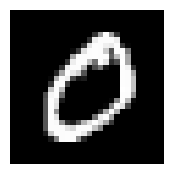

In [25]:
plt.rcParams['figure.figsize']=(2,2)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이배열로 읽기(pip install opencv-python==4.8.1.78)

In [28]:
%pip install opencv-python==4.8.1.78

Note: you may need to restart the kernel to use updated packages.


In [66]:
import cv2
# 사진이미지를 흑백포맷으로 넘파이배열로 읽어오기
image_array = cv2.imread('data/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_array.shape, type(image_array)

((408, 612), numpy.ndarray)

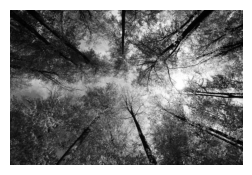

In [67]:
plt.figure(figsize=(3,4))
plt.imshow(image_array, cmap='gray')
plt.axis('off')
plt.show()

# 1. 데이터 생성 및 전처리

In [68]:
(X_train, y_train),(X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [69]:
value, counts = np.unique(y_train, return_counts=True)
ratios = counts/y_train.shape[0]
dict(zip(value, ratios))

{0: 0.09871666666666666,
 1: 0.11236666666666667,
 2: 0.0993,
 3: 0.10218333333333333,
 4: 0.09736666666666667,
 5: 0.09035,
 6: 0.09863333333333334,
 7: 0.10441666666666667,
 8: 0.09751666666666667,
 9: 0.09915}

In [70]:
value, counts = np.unique(y_test, return_counts=True)
ratios = counts/y_test.shape[0]
dict(zip(value, ratios))

{0: 0.098,
 1: 0.1135,
 2: 0.1032,
 3: 0.101,
 4: 0.0982,
 5: 0.0892,
 6: 0.0958,
 7: 0.1028,
 8: 0.0974,
 9: 0.1009}

7


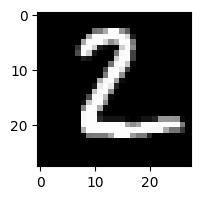

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0116125171255255150 93  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0169253253253253253253218 30  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0169253253253213142176253253122  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 52250253210 32 12  0  6206253140  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0 77251210 25  0  0  0122248253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 31 18  0  0  0  0209253253 65  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0117247253198 10  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0 76247253231 63  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0128253253144  0  0  0  0  0  

In [71]:
print(y_test[0])
plt.imshow(X_test[1], cmap='gray')
plt.show()
for row in X_test[1]:
    for pixel in row:
        print(f"{pixel:3.0f}", end="")
    print()

In [72]:
# Train데이터 6만개 -> Train(5만개) + val(만개)로 분리
(X_train, y_train), (X_test, y_test) = mnist.load_data() # 6만개, 만개로 분리되어 Load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [73]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [87]:
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [88]:
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [89]:
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# idx = random.sample(range(50000), 700)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]

# 2. 모델 구성
# 3. 학습과정 설정

In [92]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 학습과정 설정 : 타겟변수를 원핫인코딩 안했다면 spqrse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam', metrics=['accuracy']) # 평가지표

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 2)                 1570      
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 2)                 0         
                                                                 
 dense_5 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습

In [96]:
%%time
hist = model.fit(train_X, train_Y, # 학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=100,
                epochs=200)

Epoch 1/200
7/7 [==============================] - 0s 15ms/step - loss: 1.1225 - accuracy: 0.6286 - val_loss: 1.5212 - val_accuracy: 0.5000
Epoch 2/200
7/7 [==============================] - 0s 6ms/step - loss: 1.1189 - accuracy: 0.6286 - val_loss: 1.5221 - val_accuracy: 0.4767
Epoch 3/200
7/7 [==============================] - 0s 6ms/step - loss: 1.1166 - accuracy: 0.6286 - val_loss: 1.5214 - val_accuracy: 0.4767
Epoch 4/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1127 - accuracy: 0.6286 - val_loss: 1.5183 - val_accuracy: 0.5000
Epoch 5/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1095 - accuracy: 0.6271 - val_loss: 1.5174 - val_accuracy: 0.4833
Epoch 6/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1059 - accuracy: 0.6286 - val_loss: 1.5161 - val_accuracy: 0.4967
Epoch 7/200
7/7 [==============================] - 0s 7ms/step - loss: 1.1029 - accuracy: 0.6257 - val_loss: 1.5150 - val_accuracy: 0.4900
Epoch 8/200
7/7 [=========

7/7 [==============================] - 0s 8ms/step - loss: 0.8949 - accuracy: 0.7000 - val_loss: 1.4913 - val_accuracy: 0.5433
Epoch 118/200
7/7 [==============================] - 0s 7ms/step - loss: 0.8939 - accuracy: 0.6957 - val_loss: 1.4917 - val_accuracy: 0.5433
Epoch 119/200
7/7 [==============================] - 0s 8ms/step - loss: 0.8927 - accuracy: 0.7000 - val_loss: 1.4909 - val_accuracy: 0.5400
Epoch 120/200
7/7 [==============================] - 0s 8ms/step - loss: 0.8915 - accuracy: 0.7014 - val_loss: 1.4927 - val_accuracy: 0.5400
Epoch 121/200
7/7 [==============================] - 0s 7ms/step - loss: 0.8903 - accuracy: 0.7000 - val_loss: 1.4936 - val_accuracy: 0.5400
Epoch 122/200
7/7 [==============================] - 0s 7ms/step - loss: 0.8887 - accuracy: 0.7014 - val_loss: 1.4950 - val_accuracy: 0.5467
Epoch 123/200
7/7 [==============================] - 0s 8ms/step - loss: 0.8881 - accuracy: 0.6971 - val_loss: 1.4930 - val_accuracy: 0.5400
Epoch 124/200
7/7 [========

# 5. 모델평가하기

In [99]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

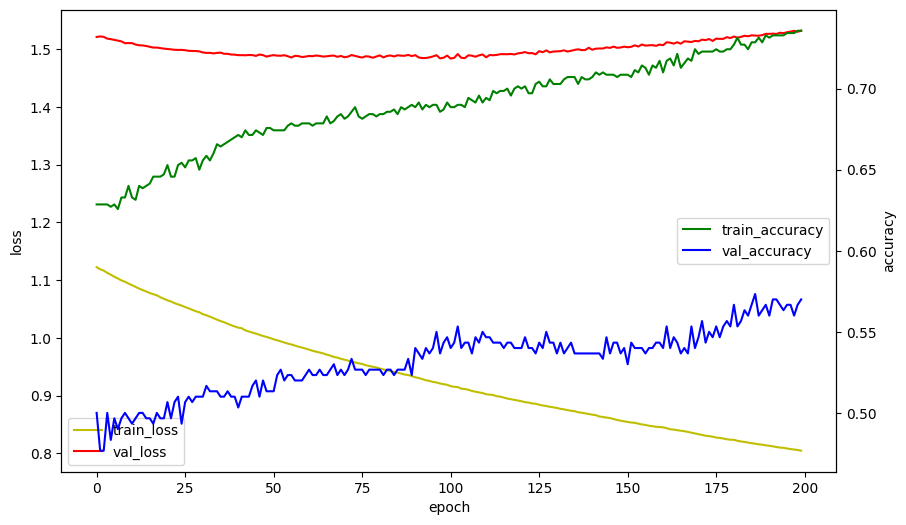

In [100]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

loss_ax.legend()
acc_ax.legend(loc='center right')

In [103]:
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.5767674446105957
accuracy : 0.5386000275611877


# 👌 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, 활성화 함수를 relu계열, tahn, Dropout추가, 배치정규화, L2정규화(규제)...)
- epoch 조정
- optimizer 변경

In [116]:
%%time
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0

# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)

# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
# train_idx = np.random.choice(50000, 2000, replace=False) # 0~50000미만의 700개 수 비복원추출
# val_idx = np.random.choice(10000, 1000, replace=False)
# train_X = train_X[train_idx]
# train_Y = train_Y[train_idx]
# val_X   = val_X[val_idx]
# val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)

# 모델생성(784 -> 1024 -> 512 -> 128 -> 10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))

model.add(Dense(units=1024))
model.add(BatchNormalization()) # 출력층을 배치 정규화
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dropout(0.2))

model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표

# 모델 학습
hist = model.fit(
                train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 숫자가 크면 학습속도 ↑ 메모리 부족 ↓
                epochs=30, 
                # verbose=0
                )

(50000, 784) (50000, 10) (10000, 784) (10000, 10) (10000, 784) (10000, 10)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_36 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 leaky_re_lu_19 (LeakyReLU)  (None, 1024)              0         
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_37 (Dense)            (None, 512)               524800    
                                                                 
 batch_normalization_1 (Batc  (None, 512)      

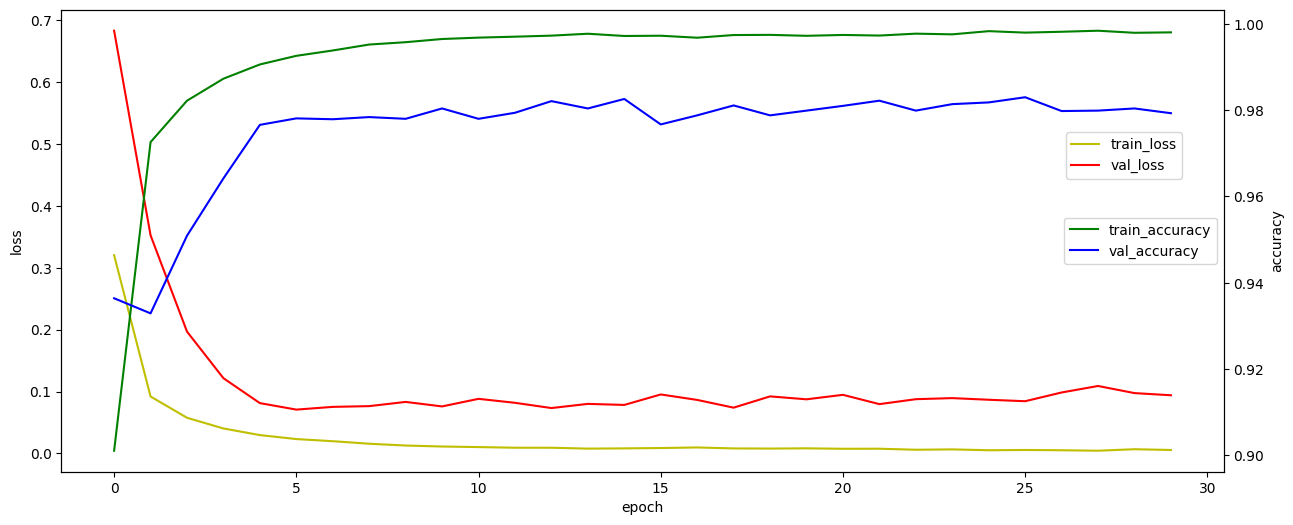

loss : 0.08944573998451233
accuracy : 0.9800999760627747


In [117]:
# 학습과정 살펴보기(시각화)
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(bbox_to_anchor=(0.97,0.75))
acc_ax.legend(loc='center right')
plt.show()
# 모델 평가(시험셋=test셋)
loss_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

In [126]:
# 교차표
y_test # 실제값
test_Y.argmax(axis=1)
np.all(test_Y.argmax(axis=1) == y_test)

True

In [127]:
y_hat = model.predict(test_X).argmax(axis=1) # 예측값
y_hat = np.argmax(model.predict(test_X), axis=1)
y_hat

313/313 [==============================] - 2s 5ms/step


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [133]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,974,1,0,0,0,0,1,1,3,0
1,0,1127,3,2,0,0,0,1,2,0
2,4,3,1013,3,1,0,0,4,4,0
3,0,0,5,996,0,1,0,3,3,2
4,2,1,6,0,959,0,3,1,1,9
5,3,0,0,25,0,858,4,0,1,1
6,3,2,0,0,1,6,946,0,0,0
7,1,3,7,2,1,0,0,1007,2,5
8,0,0,4,16,1,4,0,4,940,5


In [131]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[ 974,    1,    0,    0,    0,    0,    1,    1,    3,    0],
       [   0, 1127,    3,    2,    0,    0,    0,    1,    2,    0],
       [   4,    3, 1013,    3,    1,    0,    0,    4,    4,    0],
       [   0,    0,    5,  996,    0,    1,    0,    3,    3,    2],
       [   2,    1,    6,    0,  959,    0,    3,    1,    1,    9],
       [   3,    0,    0,   25,    0,  858,    4,    0,    1,    1],
       [   3,    2,    0,    0,    1,    6,  946,    0,    0,    0],
       [   1,    3,    7,    2,    1,    0,    0, 1007,    2,    5],
       [   0,    0,    4,   16,    1,    4,    0,    4,  940,    5],
       [   2,    2,    0,    6,    9,    4,    0,    4,    1,  981]],
      dtype=int64)

In [134]:
# 틀린개수
accuracy = loss_metrics[1]
10000 - 10000 * accuracy

199.00023937225342

# ※ 콜백함수 1: 로그출력

In [2]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
%%time
# 특정 에포크마다 로그출력을 하도록 제한하는 callback 클래스
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        '1 epoch 수행 후 자동 실행되는 함수'
        self.epoch += 1
        if self.epoch%10==0: # 10에포크마다 로그출력
            print('epoch:{}, loss:{:.4f}, acc:{:.4f}, val_loss:{:.4f}, val_acc:{:.4f}'\
                  .format(self.epoch,
                         logs.get('loss', '-'),
                         logs.get('accuracy', '-'),
                         logs.get('val_loss', '-'),
                         logs.get('val_accuracy', '-')
                         )
                 )
            
(X_train, y_train),(X_test, y_test) = mnist.load_data() #6만개, 만개로 분리되어 load
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n,28,28) -> (n, 28*28) -> 실수로 형변환 ->스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(10000, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 종속(타겟)변수 : 분류분석을 위한 원핫인코딩(to_categorical()이용, pd.getdummies)
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만 -> 임의로 700개, val 1만 -> 임의로 300개 추출해서 학습(목적:수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 700개 수 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
print(train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape)
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
customHistory = CustomHistory()
print(customHistory.epoch)
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=0,
                callbacks=[customHistory] 
                )

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [ ]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 학습
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=3) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping] 
                )

# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_acc(va_loss, loss, acc)값이 좋을 때마다 모델을 자동 저장하는 콜백

In [ ]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 모델 자동 저장 콜백
import os
model_save_folder = 'model07/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist_{epoch:03d}_val{val_accuracy:.4f}.h5'
checkpoint = ModelCheckpoint(filepath=file,
                            monitor='val_accuracy', # 모니터할 지표(기본값은 val_loss)
                            save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                            mode = 'max', # 값이 커질수록 저장
                            verbose=1 
                            )

earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, checkpoint] 
                )

In [ ]:
# 최종 학습 모델
model.evaluate(test_X, test_Y)

In [ ]:
# 저장된 모델 중 최선의 모델
model2 = load_model('model07/mnist_038_val0.3067.h5')
model2.evaluate(test_X, test_Y)

# ※ 콜백함수 4 : ReduceLROnPlateau
- 성능이 정체될 때 학습률(learning_rate)을 낮춰서 더 세밀하게 최적점을 찾도록 도와주는 콜백

In [ ]:
%%time
# 모델생성(784 -> 2->10) 및 학습과정 설정
model = Sequential(name='sequential')
model.add(Input(shape=(784,)))
model.add(Dense(units=2))
model.add(LeakyReLU(alpha=0.01)) # 음수 결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))

# 학습과정 설정 : 타겟변수를 원핫인코딩 안 했다면 sparse_categorical_crossentropy
model.compile(loss='categorical_crossentropy', 
             # optimizer=Adam(learning_rate=0.001)
             optimizer='adam',
             metrics=['accuracy']) # 평가지표
# 성능 정체시 학습률 낮추는 콜백
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy',
                              patience=2,
                              factor=0.5,
                              min_lr=1e-6)

earlyStopping = EarlyStopping(monitor='val_accuracy', patience=10) # 조기종료 콜백
hist = model.fit(train_X, train_Y, #학습셋
                validation_data=(val_X, val_Y), # 검증셋
                batch_size=1000, # 크면 학습속도는 빨라지나 메모리 부족이 뜰 수도
                epochs=200, 
                verbose=2,
                callbacks=[earlyStopping, reduce_lr] 
                )